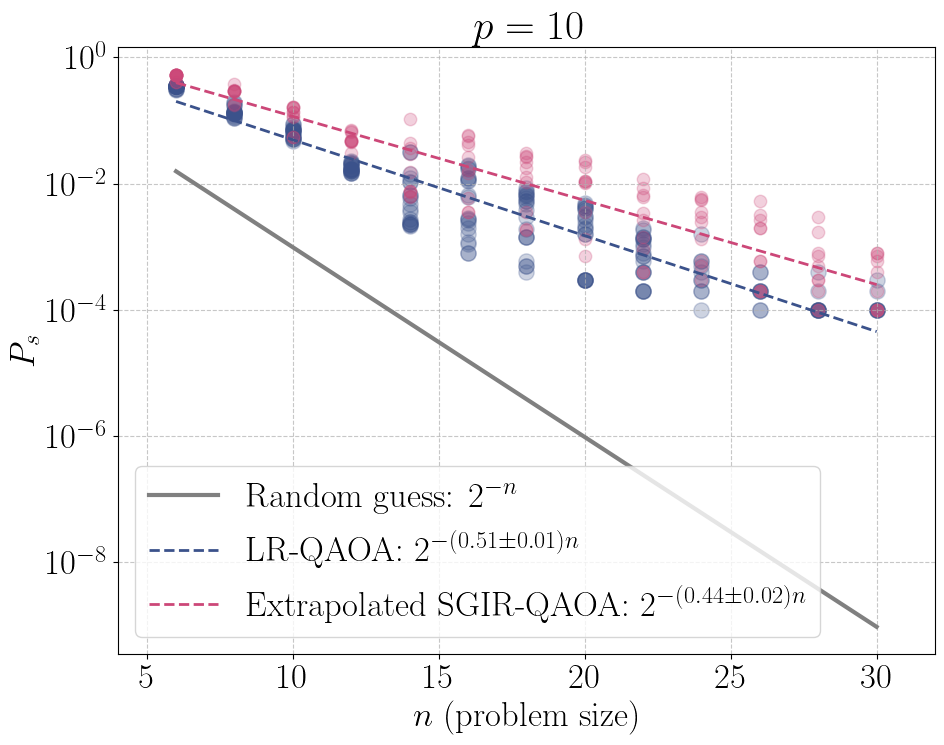

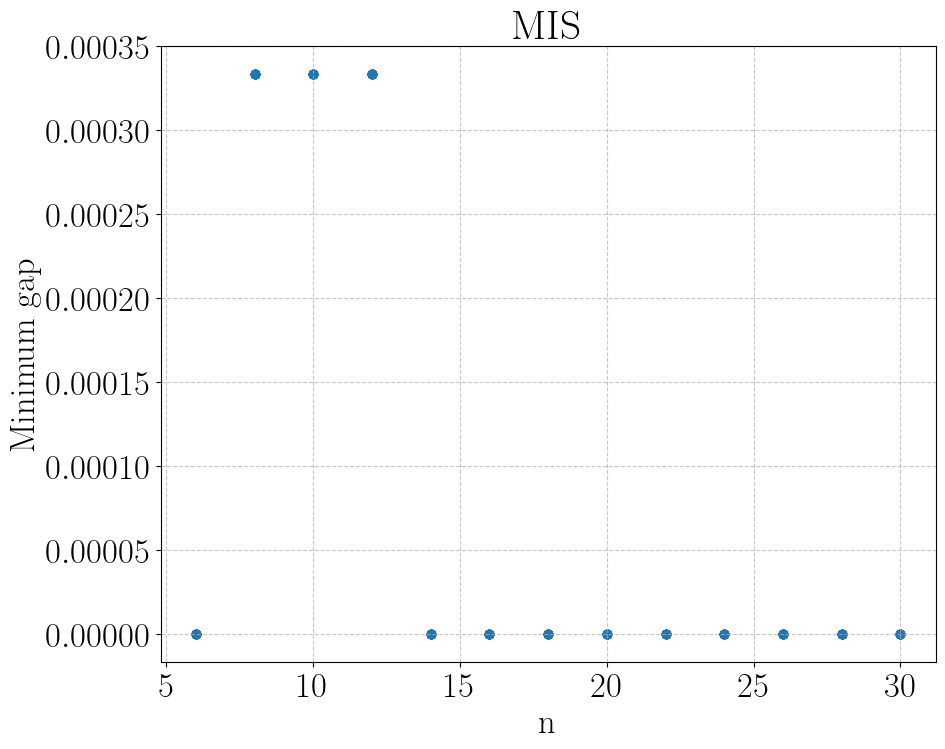

In [ ]:
# -*- coding: utf-8 -*-
"""

Plot MIS Results at constant depth

"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os

# =========================
# Parameters
# =========================
n_max = 30


p = 10
pen = 2000
pe = 'd3'

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'font.size': 25})

# =========================
# CSV files
# =========================

# d3
csv_LR = f"results/instances_d3_statevector_degenCheckaccNO_no_renorm_pen2000_LR-QAOA_2026_10_b[-1.5, 0.5]_g[-1, 1]_d11.csv"
# csv_LR2 = f"results/instances_d3_statevector_degenCheckN_no_renorm_pen2000_LR-QAOA_2026_10_b[-1.5, 0.5]_g[-1, 1]_d11.csv"


# d3 extrap
csv_SG = f"results/instances_d3_statevector_degenCheckN_no_renorm_pen2000_SGIR-QAOA-0k_matrix_free_extrap_s0_gap4all_s1_gap0_2026_10_b[-1.5, 0.5]_g[-1, 1]_d11.csv"

csv_rand = f"results/big_random_{p}_b[-1.5, 0.5]_g[-1, 1]_d11_vRand.csv"
csv_SG_inv = f""



# =========================
# Load CSVs
# =========================
try:
    df1     = pd.read_csv(csv_LR)
    df2      = pd.read_csv(csv_LR2)
    # ---- Concatenate ----
    df = pd.concat([df1, df2], ignore_index=True)

    # df_SG1 = pd.read_csv(csv_SG)
    # df_SG2 = pd.read_csv(csv_SG2)
    # df_SG = pd.concat([df_SG1, df_SG2], ignore_index=True)

except:
    df = pd.read_csv(csv_LR)
    df_SG = pd.read_csv(csv_SG)


df_rand = pd.read_csv(csv_rand) if os.path.exists(csv_rand) else None
df_SG_inv = pd.read_csv(csv_SG_inv, on_bad_lines='skip') if os.path.exists(csv_SG_inv) else None



def add_n_column(df, instance_col="instance"):
    """
    Extracts n from filenames like:
    mis_d3_n6_7.gpickle
    mis_d3_n12_10.gpickle
    """
    df = df.copy()
    df["n"] = (
        df[instance_col]
        .str.extract(r"_n(\d+)_", expand=False)
        .astype(int)
    )
    return df

# df = df[:40]
# df_SG = df_SG[:40]

df = add_n_column(df)
df_SG  = add_n_column(df_SG )

n_max = n_max  # choose your threshold

df = df[df["n"] <= n_max]
df_SG  = df_SG [df_SG ["n"] <= n_max]

# =========================
# Methods
# =========================
methods = [
    ("LR-QAOA", df, cm.viridis(0.25), 0.0),
    ("Extrapolated SGIR-QAOA", df_SG, cm.plasma(0.5), 0.0),
    ("Random params", df_rand, "black", 0.0),
    ("LR-QAOA-CD-peakGap", df_SG_inv, "red", 0.2)
]

fit_records = []

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 8))

# ----- baseline 2^{-n} -----
n_vals = np.unique(
    np.concatenate([
        df_["n"].values for _, df_, _, _ in methods
        if df_ is not None and "n" in df_.columns
    ])
)

n_ref = np.linspace(n_vals.min(), n_max, 300) # n_vals.max()
plt.plot(
    n_ref,
    2 ** (-n_ref),
    color="gray",
    linewidth=3,
    label=r"Random guess: $2^{-n}$"
)

# ----- loop over methods -----
for label, df_, color, offset in methods:
    if df_ is None:
        continue
    if "n" not in df_.columns or "Ps_avg" not in df_.columns:
        continue

    # Scatter
    s = 120 if label == "LR-QAOA" else 80
    plt.scatter(
        df_["n"] + offset,
        df_["Ps_avg"],
        color=color,
        alpha=0.25,
        s=s

    )

    # ----- fit over ALL n (in log2 space) -----
    df_fit = df_[(df_["Ps_avg"] > 0)].copy()
    if len(df_fit) < 2:
        continue

    df_fit["logPs"] = np.log2(df_fit["Ps_avg"])

    # Fit with covariance to get errors
    popt, pcov = np.polyfit(df_fit["n"], df_fit["logPs"], 1, cov=True)
    m, b = popt
    m_err, b_err = np.sqrt(np.diag(pcov))
    alpha = -m
    alpha_err = m_err

    # Smooth line for plotting
    n_line = np.linspace(df_fit["n"].min(), df_fit["n"].max(), 300)
    Ps_fit = 2 ** (m * n_line + b)

    # Optional: uncertainty band
    sigma_logPs = np.sqrt((n_line * m_err)**2 + b_err**2)
    Ps_upper = 2 ** (m * n_line + b + sigma_logPs)
    Ps_lower = 2 ** (m * n_line + b - sigma_logPs)

    # Plot fit line
    plt.plot(
        n_line,
        Ps_fit,
        linestyle="--",
        linewidth=2,
        color=color,
        label=rf"{label}: $2^{{-({alpha:.2f} \pm {alpha_err:.2f}) n}}$"
    )



# =========================
# Formatting
# =========================
plt.xlabel(r"$n$ (problem size)")
plt.ylabel(r"$P_s$")
plt.yscale("log")
plt.xlim(4,n_max+2)
plt.title(rf"$p = {p}$")
plt.legend(fontsize=25)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"plots/big_plot_MIS_p{p}_base2_fits_{pe}_pen{pen}.pdf")
plt.show()

# =========================
# Save fit coefficients
# =========================
fit_df = pd.DataFrame(fit_records)
fit_df.to_csv(f"results/fit_coeffs_p{p}_{pe}_pen{pen}.csv", index=False)



## Plot min gap size



# Extract variables
n = df_SG["n"]
min_gap = df_SG["Min gap"]

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(n, min_gap)
plt.xlabel("n")
plt.ylabel("Minimum gap")
plt.title("MIS")
# plt.ylim(0,0.1)
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig(f"plots/gap_size_with_n_MIS_{pe}_pen{pen}.pdf")

plt.show()